In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [3]:
df=pd.read_csv('height-weight.csv')
df.head(5)

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


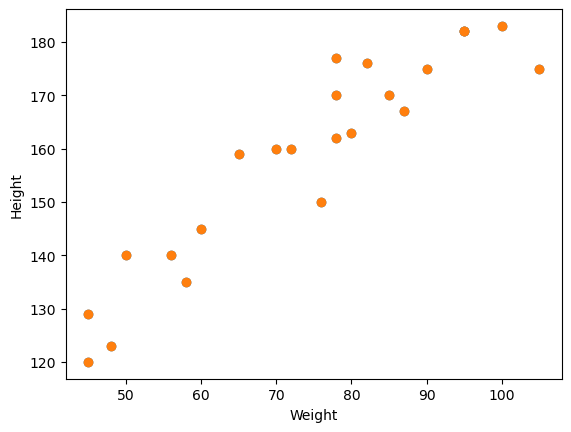

In [5]:
## Scatter plots
plt.scatter(df['Weight'],df['Height'])
plt.xlabel("Weight")
plt.ylabel("Height")
plt.show()

In [6]:
## Finding Correlation
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


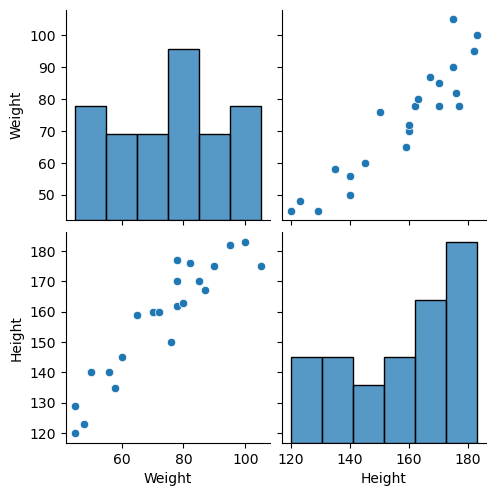

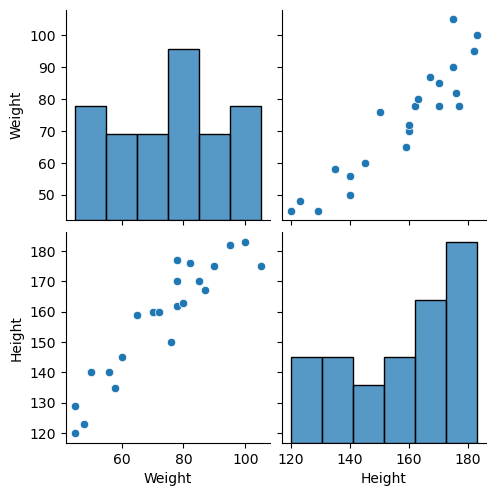

In [10]:
## Seaborn for visualization
import seaborn as sns
sns.pairplot(df)
plt.show()

In [13]:
## Independent and dependent features
X=df[['Weight']] 
### Independent feature must be in 2-D array,
### else it will be in series
X.head()

y=df['Height'] # Dependent featre, so 1-D or series works

In [14]:
### Train Test Data Split
from sklearn.model_selection import train_test_split

In [16]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25)

In [17]:
X_train.shape

(17, 1)

In [18]:
y_train.shape

(17,)

In [ ]:
### Standardization
### Applying Z-Score for u=0 and standard deviation = 1
### z = (x - u) / s

In [19]:
from sklearn.preprocessing import StandardScaler

In [21]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)

In [23]:
X_train

array([[-1.51218144],
       [ 0.7948646 ],
       [-0.96288476],
       [ 1.61880962],
       [-0.85302543],
       [ 0.6300756 ],
       [ 1.34416128],
       [-1.67697044],
       [ 1.06951294],
       [ 0.13570859],
       [ 0.13570859],
       [-0.19386941],
       [ 0.02584926],
       [ 1.06951294],
       [ 0.35542726],
       [-1.4023221 ],
       [-0.57837709]])

In [ ]:
## Since we dont want our test data to know any
## info about training data, therefore to avoid
## the data leakage problem, we just do transform
## and not fit_transform in Test data

In [24]:
X_test=scaler.transform(X_test)

In [25]:
X_test

array([[-1.0727441 ],
       [-0.30372875],
       [ 0.52021626],
       [ 0.13570859],
       [-1.67697044],
       [ 0.24556793]])

In [26]:
## Apply Simple Linear Regression
from sklearn.linear_model import LinearRegression

In [31]:
regression=LinearRegression(n_jobs=-1)

In [32]:
regression.fit(X_train,y_train)

LinearRegression(n_jobs=-1)

In [38]:
print("Coeff or slope:",regression.coef_) # 1 independent feature => 1 coef
print("Intercept:",regression.intercept_)

Coeff or slope: [18.48050695]
Intercept: 159.05882352941177


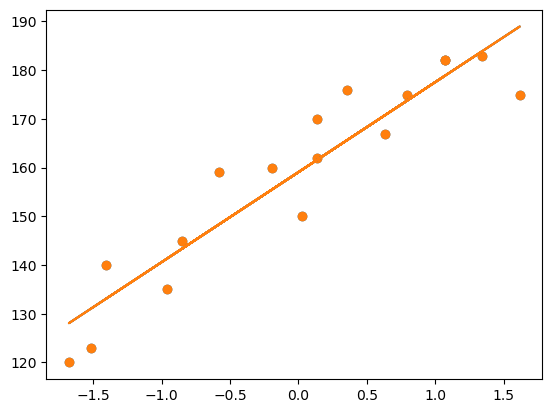

In [40]:
## Plot best fit line wrt the training data
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train))
plt.show()

## Prediction for the test data

1. Predicted height output = intercept + coef_(Weights)
2. y_pred_test = 159.058 + 18.480(X_test)

In [42]:
## Prediction for the test data
y_pred=regression.predict(X_test)

In [43]:
## Performance Matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [44]:
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

47.452761877650765
4.268380280219669
6.888596510004833


## R Square
Formula:

R^2 = 1 - SSR/SST 


R^2 = Coeff of determination

SSR = Sum of Square of Residuals

SST = Total Sum of Squares

In [45]:

from sklearn.metrics import r2_score

In [48]:
score=r2_score(y_test,y_pred)
print(score)

0.8310788660540465


### Adjusted R2 = 1 - [(1-R2)*(n-1)/(n-k-1)]

where:

R2: The R2 of model 

n: The number of observations

k: The number of predictor variables

In [49]:
## Display adjusted R-Squared
1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.7888485825675581

In [50]:
### OLS Linear Regression
import statsmodels.api as sm

In [51]:
model=sm.OLS(y_train,X_train).fit()

In [53]:
prediction=model.predict(X_test)
print(prediction)

[-19.82485473  -5.61306128   9.61386027   2.50796355 -30.99126386
   4.53821976]


In [54]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.013
Model:                            OLS   Adj. R-squared (uncentered):             -0.048
Method:                 Least Squares   F-statistic:                             0.2156
Date:                Fri, 31 Oct 2025   Prob (F-statistic):                       0.649
Time:                        08:27:25   Log-Likelihood:                         -110.32
No. Observations:                  17   AIC:                                      222.6
Df Residuals:                      16   BIC:                                      223.5
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

c:\Users\OMEN\Downloads\MLOPS\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=17 observations were given.
  return hypotest_fun_in(*args, **kwds)


In [55]:
## Prediction for the new data
regression.predict([[72]])

array([1489.65532387])

In [57]:
regression.predict(scaler.transform([[72]]))

c:\Users\OMEN\Downloads\MLOPS\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([155.47601846])